# Ray Calculation

In [1]:
import numpy as np
from astropy import units as u
import csv

In [2]:
from matplotlib import pyplot as plt

In [3]:
from radial_interpolation import *
from radial import sm

hello again


In [4]:
from interp_and_iat_2d import *

120
59 59 0.005 arcsec True


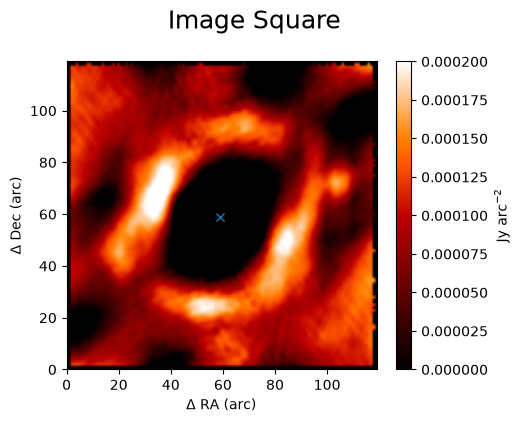

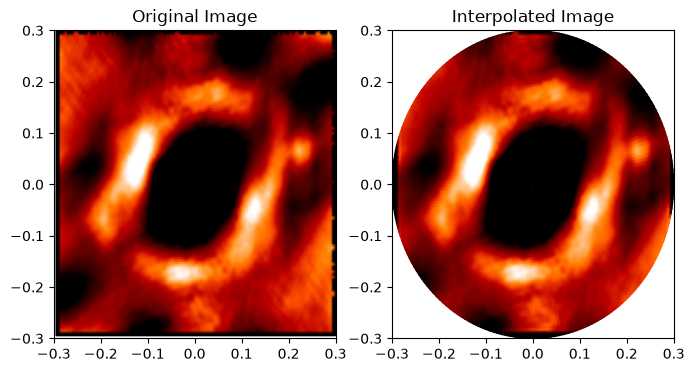

(201, 100)


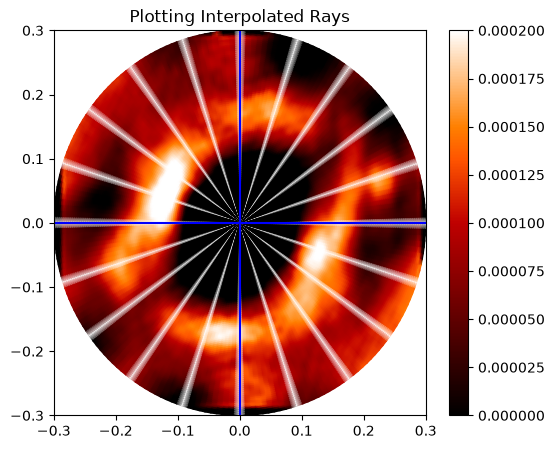

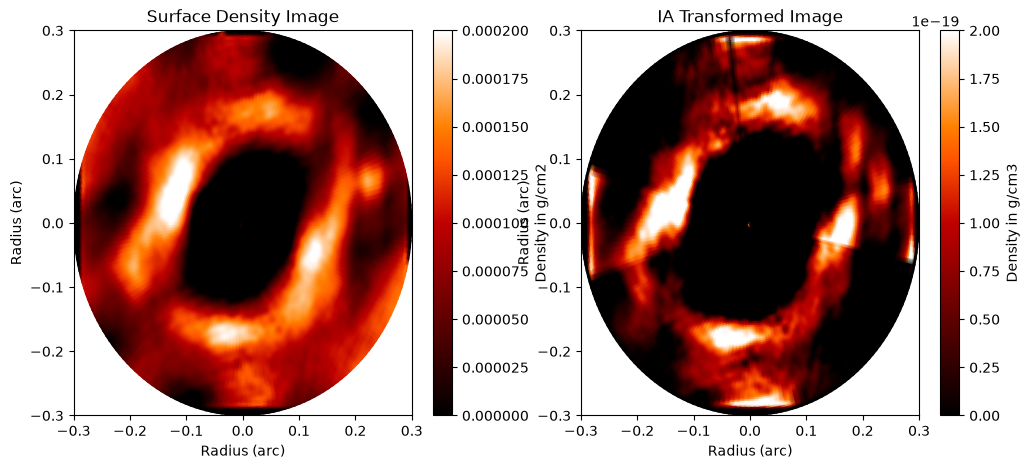

In [5]:
x_grid_csm,y_grid_csm,interp_csm,radius_2d_arc_csm,radius_2d_pc_csm,csm_abel = read_in_density_file("saved_data/csm_2d_density.csv",center_x=499,center_y=499,vmax_gcm2=0.0002, vmax_gcm3=2e-19,
                                                                   pix_size_arcsec = 0.005 * u.arcsec,csm=True,return_grids=True)

/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


(1e-20, 1e-12)

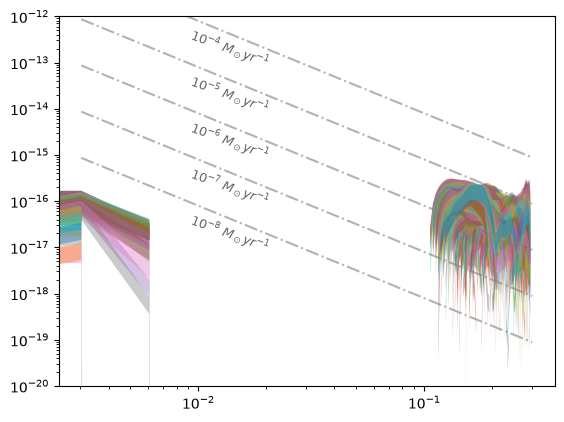

In [6]:
for i in range(radius_2d_arc_csm.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    plt.fill_between(radius_2d_arc_csm[i,],csm_abel[i,]+csm_abel[i,]*430,csm_abel[i,]+csm_abel[i,]*1000,alpha=0.4)

mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*radius_2d_pc_csm[0,].to(u.cm)**2*v_yr)
    plt.plot(radius_2d_arc_csm[0,], rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = radius_2d_arc_csm[0,3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/120

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-20, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.ylim(10**-20,10**-12)

In [7]:
csm_abel_zero = np.zeros_like(csm_abel)
for i in range(radius_2d_arc_csm.shape[0]):
    for j in range(radius_2d_arc_csm.shape[1]):
        if radius_2d_arc_csm[i,j]>0.1:
            csm_abel_zero[i,j]=csm_abel[i,j]

In [8]:
from matplotlib.pyplot import cm

In [9]:
def plot_lines(rad,data,color):
    c=0
    for i in range(rad.shape[0]):
        #plt.plot(radius_2d_arc[i,], csm_abel[i,])
        if i%25==0:
            plt.fill_between(rad[i,],data[i,]+data[i,]*430,data[i,]+data[i,]*1000,color = color[i],alpha=.3)
            print(data[i,0])
            c+=1
    print(c," lines plotted")

lines shown:  9


Text(0.5, 1.0, 'Inverse Abel Transform for CSM Rays')

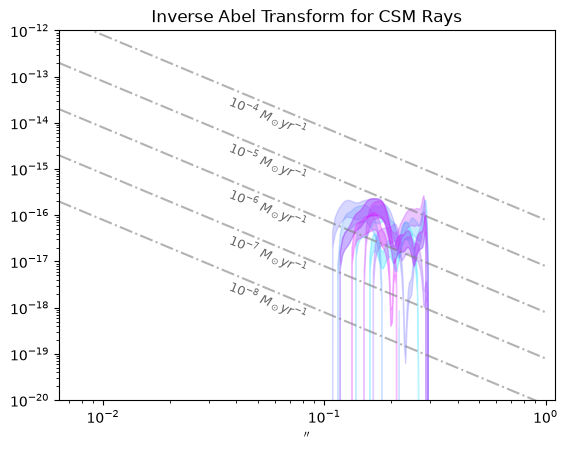

In [10]:
count=0
color = cm.cool(np.linspace(0, 1, 201))
for i in range(radius_2d_arc_csm.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    if i%25==0:
        count+=1
        plt.fill_between(radius_2d_arc_csm[i,],csm_abel[i,]+csm_abel[i,]*430,csm_abel[i,]+csm_abel[i,]*1000,color = color[i],alpha=.3)
print("lines shown: ", count)
mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

plt.ylim(10**-20,10**-12)
plt.xlim(1*10**-2.2,1.1)

x_range = np.linspace(1*10**-2.2,1,100)*u.arcsec
x_range_pc = sm(168,x_range).value*u.pc

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*x_range_pc.to(u.cm)**2*v_yr)
    plt.plot(x_range, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = x_range[3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/65

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-22, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.title("Inverse Abel Transform for CSM Rays")

lines shown:  21


Text(0.5, 1.0, 'Inverse Abel Transform for CSM Rays')

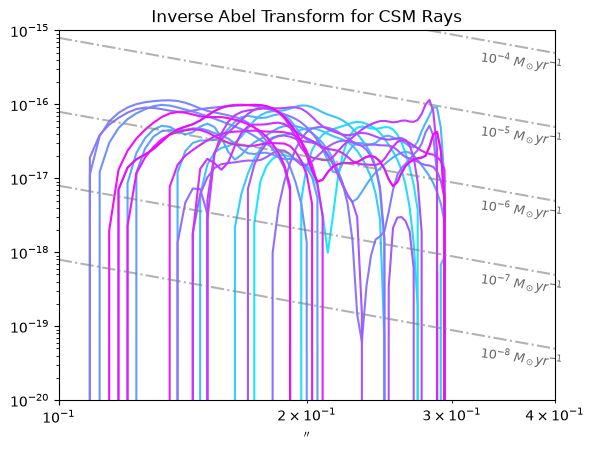

In [22]:
count=0
color = cm.cool(np.linspace(0, 1, 22))
for i in range(radius_2d_arc_csm.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    if i%10==0:
        count+=1
        plt.plot(radius_2d_arc_csm[i,],csm_abel[i,]+csm_abel[i,]*430,color = color[count],alpha=1)
print("lines shown: ", count)
mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

plt.ylim(10**-20,10**-15)
plt.xlim(1*10**-1,.4)

x_range = np.linspace(1*10**-1,1.1)*u.arcsec
x_range_pc = sm(168,x_range).value*u.pc

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*x_range_pc.to(u.cm)**2*v_yr)
    plt.plot(x_range, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = x_range[11]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/35

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-7, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.title("Inverse Abel Transform for CSM Rays")

In [33]:
import matplotlib.colors

In [63]:
def discrete_cmap(N, base_cmap=None):
    """Create an N-bin discrete colormap from the specified input map"""

    # Note that if base_cmap is a string or None, you can simply do
    #    return plt.cm.get_cmap(base_cmap, N)
    # The following works for string, None, or a colormap instance:

    base = plt.get_cmap(base_cmap)
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)#plt.cm.colors.LinearSegmentedColormap.from_list(cmap_name, color_list, N)


In [64]:
colors = discrete_cmap(21,base_cmap='cubehelix')

In [ ]:
colors.

1

In [136]:
def plot_rayss(x_grid,y_grid,interp_star,vmax=v_max,shift=True):
    '''
    data validation step to show polar alignment
    '''
    # making temp dataset to add rays of a different value
    # this will plot as radial lines
    interp_box_temp = np.zeros((len(interp_star),len(interp_star[0])))
    plt.figure(figsize=(6,5))
    # making rays for reference
    count = 0
    prev_i=0
    for i in range(len(interp_star)):
        #for j in range(len(interp_star[0])):
            #print(i)
        if i%10==0:
            if (i!=prev_i or i==0) and i!=200:
                count+=1
                plt.plot(x_grid[i,],y_grid[i,],color = color[count])
                print(i)
            
            #print(i,j)
            prev_i=i

    print(count)
    

    plt.pcolormesh(x_grid,y_grid,interp_star,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = vmax)

    rnge = 0.3

    plt.xlim(-rnge,rnge)
    plt.ylim(-rnge,rnge)

    # plt.vlines(0,-10,10,colors='blue')
    # plt.hlines(0,-10,10,colors='blue')

    plt.title("Plotting Interpolated Rays")
    plt.colorbar()


In [137]:
cy

0

In [138]:
len(interp_csm)

201

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
20


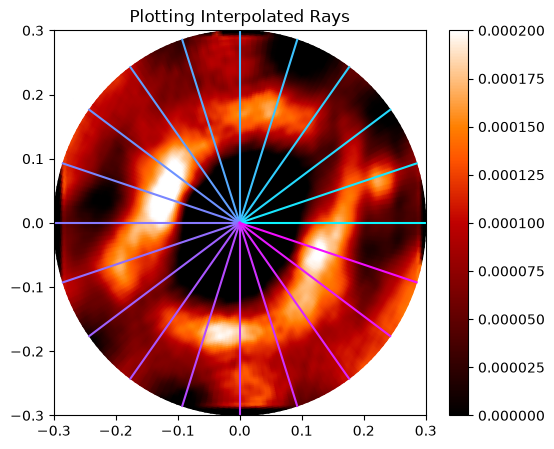

In [139]:
plot_rayss(x_grid_csm,y_grid_csm,interp_csm,vmax=0.0002,shift=True)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
21


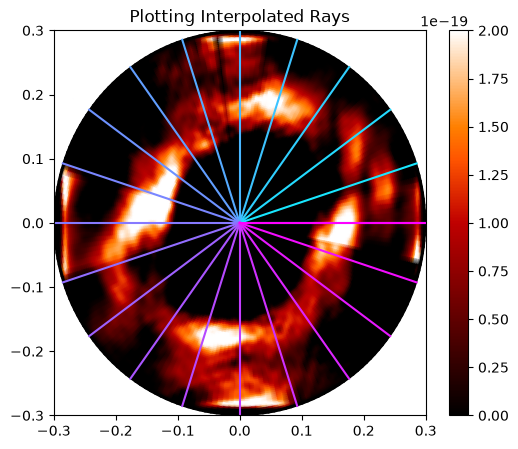

In [131]:
plot_rayss(x_grid_csm,y_grid_csm,csm_abel,vmax=2e-19,shift=True)